In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.2.2
Uninstalling torch-2.2.2:
  Successfully uninstalled torch-2.2.2
Found existing installation: torchvision 0.17.2
Uninstalling torchvision-0.17.2:
  Successfully uninstalled torchvision-0.17.2
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128


In [ ]:
!pip install -q torch torchvision torchaudio

In [ ]:
import torch

print(torch.__version__)

print(torch.cuda.is_available())

2.12.0+cu130
True


In [ ]:
!pip uninstall -y numpy pandas
!pip install numpy==1.26.4 pandas

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 3.0.3
Uninstalling pandas-3.0.3:
  Successfully uninstalled pandas-3.0.3
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires torch<2.3.0,>=2.2.0, but you have torch 2.12.0 which is incompatible.
facenet-pytorch 2.6.0 requires torchvision<0.18.0,>=0.17.0, but you have torchvision 0.27.0 which is incom

In [ ]:
!pip install -q facenet-pytorch torchvision timm tqdm

In [ ]:
# ============================================================
# STEP 1 — IMPORTS
# ============================================================

import os
import json
import math
import random
import numpy as np
import pandas as pd
from pathlib import Path

from PIL import Image
from tqdm import tqdm
from IPython.display import display
from IPython.display import Image as IPImage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models import ResNet50_Weights, VGG16_Weights
from torchvision.utils import make_grid
from torch.nn.utils import spectral_norm

from torch.utils.data import Dataset, DataLoader

from torch.cuda.amp import autocast, GradScaler

print('Imports loaded.')


Imports loaded.


In [ ]:
# ============================================================
# HYPERPARAMETERS & PATHS (FINETUNE v2 - SHARPER OUTPUTS)
# ============================================================

# ============================================================
# LATENT DIMENSIONS
# ============================================================

STYLE_DIM    = 256
IDENTITY_DIM = 512

# ============================================================
# TRAINING
# ============================================================

NUM_EPOCHS   = 100

BATCH_SIZE   = 16

# Give Generator more updates
N_CRITIC     = 1

MIXED_PREC   = True

LABEL_SMOOTH = 0.1

# ============================================================
# LEARNING RATES
# ============================================================

LR_G  = 1e-4

LR_D  = 2e-4

BETA1 = 0.0
BETA2 = 0.999

# ============================================================
# GRADIENT CLIPPING
# ============================================================

G_CLIP = 1.0

D_CLIP = 0.5

# ============================================================
# LOGGING
# ============================================================

SAVE_EVERY = 5

N_VIZ = 6

# ============================================================
# LOSS WEIGHTS
# ============================================================

LAMBDA = {

    # Slightly stronger realism pressure
    'adv'       : 2.5,

    # Keep age transformation strong
    'age_cls'   : 5.0,

    # Reduced slightly to avoid oversmoothing
    'cycle'     : 8.0,

    # Preserve identity
    'identity'  : 8.0,

    # Increase texture learning
    'perceptual': 7.0,

    # Better feature realism
    'feat_match': 6.0,

    # Unpaired training → keep OFF
    'recon'     : 0.0,

    # WGAN-GP stability
    'gp'        : 5.0,
}

print('=' * 60)
print('FINETUNE HYPERPARAMETERS LOADED')
print('=' * 60)

print(f'STYLE_DIM    : {STYLE_DIM}')
print(f'IDENTITY_DIM : {IDENTITY_DIM}')

print(f'BATCH_SIZE   : {BATCH_SIZE}')
print(f'N_CRITIC     : {N_CRITIC}')

print(f'LR_G         : {LR_G}')
print(f'LR_D         : {LR_D}')

print('Loss Weights:')
for k, v in LAMBDA.items():
    print(f'  {k:12s}: {v}')

print('=' * 60)

FINETUNE HYPERPARAMETERS LOADED
STYLE_DIM    : 256
IDENTITY_DIM : 512
BATCH_SIZE   : 16
N_CRITIC     : 1
LR_G         : 0.0001
LR_D         : 0.0002
Loss Weights:
  adv         : 2.5
  age_cls     : 5.0
  cycle       : 8.0
  identity    : 8.0
  perceptual  : 7.0
  feat_match  : 6.0
  recon       : 0.0
  gp          : 5.0


In [ ]:
# ============================================================
# STEP 2 — DEVICE
# ============================================================

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('Device:', device)

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
# ============================================================
# STEP 3 — LOAD PREPROCESSING FILES
# (produced by PREPROCESSING_V2.ipynb)
# ============================================================

BASE_PATH = '/content/drive/MyDrive/FaceAgingProject/preprocessing'
CKPT_PATH = '/content/drive/MyDrive/FaceAgingProject/checkpoints'
VIZ_PATH  = '/content/drive/MyDrive/FaceAgingProject/visualizations'

os.makedirs(CKPT_PATH, exist_ok=True)
os.makedirs(VIZ_PATH,  exist_ok=True)

# Load train / val splits saved by PREPROCESSING_V2
df_train = pd.read_csv(f'{BASE_PATH}/df_train.csv')
df_val   = pd.read_csv(f'{BASE_PATH}/df_val.csv')

# AGE_GROUPS — must match PREPROCESSING_V2 exactly
AGE_GROUPS = {
    0: (0,  10,  '0-10'),
    1: (11, 20,  '11-20'),
    2: (21, 30,  '21-30'),
    3: (31, 40,  '31-40'),
    4: (41, 50,  '41-50'),
    5: (51, 60,  '51-60'),
    6: (61, 70,  '61-70'),
    7: (71, 120, '71+'),
}

IMG_SIZE    = 128
NUM_CLASSES = 8

print('Train:', len(df_train))
print('Val  :', len(df_val))
print()
print('Age-group distribution (train):')
for g in range(NUM_CLASSES):
    n = (df_train['group'] == g).sum()
    print(f'  Group {g} ({AGE_GROUPS[g][2]:6s}): {n}')


Train: 12301
Val  : 2171

Age-group distribution (train):
  Group 0 (0-10  ): 1275
  Group 1 (11-20 ): 1275
  Group 2 (21-30 ): 2550
  Group 3 (31-40 ): 2550
  Group 4 (41-50 ): 1530
  Group 5 (51-60 ): 1275
  Group 6 (61-70 ): 996
  Group 7 (71+   ): 850


In [ ]:
# ============================================================
# STEP 4 — TRANSFORMS
# ============================================================

train_transform = T.Compose([

    T.Resize((IMG_SIZE, IMG_SIZE)),

    T.RandomHorizontalFlip(p=0.5),

    T.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    T.ToTensor(),

    T.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transform = T.Compose([

    T.Resize((IMG_SIZE, IMG_SIZE)),

    T.ToTensor(),

    T.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print('Transforms ready.')

Transforms ready.


In [ ]:
# ============================================================
# STEP 5 — DATASET
# Updated: supports curriculum learning via set_max_gap()
# ============================================================

class FaceAgingDataset(Dataset):

    def __init__(self, df, transform=None, max_gap=None):

        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.max_gap   = max_gap  # None = no restriction

        self.group_indices = {}
        for g in range(NUM_CLASSES):
            self.group_indices[g] = (
                self.df[self.df['group'] == g].index.tolist()
            )

    def set_max_gap(self, max_gap):
        """Called each epoch by the curriculum scheduler."""
        self.max_gap = max_gap

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        young_row = self.df.iloc[idx]
        young_img = Image.open(young_row['filepath']).convert('RGB')
        young_age = int(young_row['group'])

        # Curriculum: restrict max target age-group if set
        if self.max_gap is not None:
            upper = min(young_age + self.max_gap, NUM_CLASSES - 1)
        else:
            upper = NUM_CLASSES - 1

        possible_old_groups = [
            g for g in range(young_age + 1, upper + 1)
            if len(self.group_indices[g]) > 0
        ]

        if len(possible_old_groups) == 0:
            old_group = young_age
        else:
            old_group = random.choice(possible_old_groups)

        old_idx = random.choice(self.group_indices[old_group])
        old_row = self.df.iloc[old_idx]
        old_img = Image.open(old_row['filepath']).convert('RGB')
        old_age = int(old_row['group'])

        if self.transform:
            young_img = self.transform(young_img)
            old_img   = self.transform(old_img)

        return (
            young_img,
            old_img,
            torch.tensor(young_age),
            torch.tensor(old_age)
        )


# ── Curriculum scheduler ──────────────────────────────────────
def get_curriculum_max_gap(epoch):
    """
    Gradually widen the age gap during training.
    Epoch  0-19  -> max_gap 2  (only nearby groups)
    Epoch 20-49  -> max_gap 4
    Epoch 50+    -> unrestricted
    """
    if epoch < 20:
        return 2
    elif epoch < 50:
        return 4
    else:
        return NUM_CLASSES - 1


print('Dataset class + curriculum scheduler ready.')


Dataset class + curriculum scheduler ready.


In [ ]:
# ============================================================
# STEP 6 — DATALOADERS
# ============================================================

train_dataset = FaceAgingDataset(
    df_train,
    transform=train_transform,
    max_gap=get_curriculum_max_gap(0)  # epoch-0 curriculum
)

val_dataset = FaceAgingDataset(
    df_val,
    transform=val_transform,
    max_gap=None   # no restriction for validation
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print('Train batches:', len(train_loader))
print('Val batches  :', len(val_loader))


Train batches: 768
Val batches  : 136


In [ ]:
# ── AdaIN ────────────────────────────────────────────────────
class AdaIN(nn.Module):
    def __init__(self, num_features, style_dim):
        super().__init__()
        self.norm       = nn.InstanceNorm2d(num_features, affine=False)
        self.style_proj = nn.Linear(style_dim, num_features * 2)

    def forward(self, x, style):
        x_norm         = self.norm(x)
        gamma, beta    = self.style_proj(style).chunk(2, dim=1)
        gamma          = gamma.unsqueeze(-1).unsqueeze(-1)
        beta           = beta.unsqueeze(-1).unsqueeze(-1)
        return gamma * x_norm + beta


# ── Attention Gate ────────────────────────────────────────────
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=True),
                                  nn.InstanceNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=True),
                                  nn.InstanceNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=True),
                                  nn.InstanceNorm2d(1),
                                  nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        return x * self.psi(self.relu(g1 + x1))


# ── ResBlock (bottleneck, with AdaIN) ─────────────────────────
class ResBlock(nn.Module):
    def __init__(self, channels, style_dim=None):
        super().__init__()
        self.conv1      = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.conv2      = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.use_adain  = style_dim is not None
        if self.use_adain:
            self.adain1 = AdaIN(channels, style_dim)
            self.adain2 = AdaIN(channels, style_dim)
        else:
            self.norm1  = nn.InstanceNorm2d(channels)
            self.norm2  = nn.InstanceNorm2d(channels)
        self.act        = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, style=None):
        res = x
        if self.use_adain and style is not None:
            out = self.act(self.adain1(self.conv1(x), style))
            out = self.adain2(self.conv2(out), style)
        else:
            out = self.act(self.norm1(self.conv1(x)))
            out = self.norm2(self.conv2(out))
        return self.act(out + res)


# ── Encoder block (downsample ×2) ─────────────────────────────
class EncBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x): return self.block(x)


print('Building blocks defined (AdaIN, AttentionGate, ResBlock, EncBlock).')

Building blocks defined (AdaIN, AttentionGate, ResBlock, EncBlock).


In [ ]:
class FaceEncoder(nn.Module):
    """
    ResNet50 backbone split into:
      content_feat  → (B, 256, H/16, W/16)  spatial, goes to generator
      identity_feat → (B, 512)               global, goes to ArcFace + age embedder
    """
    def __init__(self):
        super().__init__()
        bb = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.layer0 = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1
        self.layer2 = bb.layer2
        self.layer3 = bb.layer3
        self.content_head = nn.Sequential(
            nn.Conv2d(1024, 512, 1, bias=False), nn.InstanceNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512,  256, 1, bias=False), nn.InstanceNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
        )
        self.identity_head = nn.Sequential(
            bb.layer4, bb.avgpool, nn.Flatten(),
            nn.Linear(2048, 512), nn.BatchNorm1d(512),
        )

    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.content_head(x), self.identity_head(x)


class ArcFaceNet(nn.Module):
    """Frozen identity verifier — 512-dim L2-normalized embedding."""
    def __init__(self):
        super().__init__()
        bb = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(
            bb.conv1, bb.bn1, bb.relu, bb.maxpool,
            bb.layer1, bb.layer2, bb.layer3, bb.layer4, bb.avgpool,
        )
        self.flatten = nn.Flatten()
        self.embed   = nn.Linear(2048, IDENTITY_DIM)
        for p in self.parameters(): p.requires_grad = False

    def forward(self, x):
        return F.normalize(self.embed(self.flatten(self.features(x))), dim=1)


print('Encoder and ArcFaceNet defined.')

Encoder and ArcFaceNet defined.


In [ ]:
class AgeEmbedder(nn.Module):
    """(age_label, identity_vec) → style vector for AdaIN injection."""
    def __init__(self, num_classes, identity_dim, style_dim):
        super().__init__()
        self.age_embed = nn.Embedding(num_classes, 64)
        in_dim = 64 + identity_dim
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 512), nn.LayerNorm(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 512),    nn.LayerNorm(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, style_dim), nn.LayerNorm(style_dim),
        )

    def forward(self, age_label, identity_vec):
        return self.mlp(torch.cat([self.age_embed(age_label), identity_vec], dim=1))


print('AgeEmbedder defined.')

AgeEmbedder defined.


In [ ]:
class Generator(nn.Module):
    """
    UNet: 128→64→32→16→8 (encode) → bottleneck AdaIN → 16→32→64→128 (decode)
    Each decode level merges with the encoder skip ONE LEVEL ABOVE it.
    F.interpolate used for upsampling — exact spatial match guaranteed.

    Verified channel map:
      e1: 64ch @64x64   e2: 128ch @32x32
      e3: 256ch @16x16  e4: 512ch @8x8   bottleneck: 512ch @8x8
      d4: up(512)→16  + att(e3=256) → cat 768 → conv 256
      d3: up(256)→32  + att(e2=128) → cat 384 → conv 128
      d2: up(128)→64  + att(e1=64)  → cat 192 → conv 64
      d1: up(64)→128  + att(e1↑=64) → cat 128 → conv 32  → out 3
    """
    def __init__(self, style_dim=STYLE_DIM):
        super().__init__()
        self.style_dim = style_dim

        # ── Encoder ───────────────────────────────────────────
        self.enc1 = EncBlock(3,   64)    # → (B,  64,  64, 64)
        self.enc2 = EncBlock(64,  128)   # → (B, 128,  32, 32)
        self.enc3 = EncBlock(128, 256)   # → (B, 256,  16, 16)
        self.enc4 = EncBlock(256, 512)   # → (B, 512,   8,  8)

        # ── Bottleneck ────────────────────────────────────────
        self.bottleneck = nn.ModuleList([
            ResBlock(512, style_dim),
            ResBlock(512, style_dim),
            ResBlock(512, style_dim),
        ])

        # ── Attention Gates (F_g=gating_ch, F_l=skip_ch, F_int) ──
        # Each gate: gating signal from decoder, skip signal from encoder
        self.att4 = AttentionGate(F_g=512, F_l=256, F_int=128)  # d4=512, e3=256
        self.att3 = AttentionGate(F_g=256, F_l=128, F_int=64)   # d3=256, e2=128
        self.att2 = AttentionGate(F_g=128, F_l=64,  F_int=32)   # d2=128, e1=64
        self.att1 = AttentionGate(F_g=64,  F_l=64,  F_int=32)   # d1=64,  e1↑=64

        # ── Decoder conv layers ───────────────────────────────
        # Level 4: cat(512, 256) = 768 → 256
        self.conv4 = nn.Conv2d(768, 256, 3, padding=1, bias=False)
        self.norm4 = nn.InstanceNorm2d(256)
        self.ada4  = AdaIN(256, style_dim)

        # Level 3: cat(256, 128) = 384 → 128
        self.conv3 = nn.Conv2d(384, 128, 3, padding=1, bias=False)
        self.norm3 = nn.InstanceNorm2d(128)
        self.ada3  = AdaIN(128, style_dim)

        # Level 2: cat(128, 64) = 192 → 64
        self.conv2 = nn.Conv2d(192, 64,  3, padding=1, bias=False)
        self.norm2 = nn.InstanceNorm2d(64)
        self.ada2  = AdaIN(64, style_dim)

        # Level 1: cat(64, 64) = 128 → 32
        self.conv1 = nn.Conv2d(128, 32,  3, padding=1, bias=False)
        self.norm1 = nn.InstanceNorm2d(32)
        self.ada1  = AdaIN(32, style_dim)

        self.act = nn.LeakyReLU(0.2, inplace=True)

        # ── Output head ───────────────────────────────────────
        self.out_conv = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1, bias=False),
            nn.InstanceNorm2d(16),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(16, 3, 1),
            nn.Tanh()
        )

    @staticmethod
    def _up(x, target):
        """Bilinear upsample x to exactly match target spatial dims."""
        return F.interpolate(x, size=target.shape[2:],
                             mode='bilinear', align_corners=False)

    def forward(self, x, style):
        # ── Encode ────────────────────────────────────────────
        e1 = self.enc1(x)    # (B,  64,  64, 64)
        e2 = self.enc2(e1)   # (B, 128,  32, 32)
        e3 = self.enc3(e2)   # (B, 256,  16, 16)
        e4 = self.enc4(e3)   # (B, 512,   8,  8)

        # ── Bottleneck ────────────────────────────────────────
        b = e4
        for res in self.bottleneck:
            b = res(b, style)  # (B, 512, 8, 8)

        # ── Decode ────────────────────────────────────────────
        # Level 4: 8 → 16  (merge with e3 @16x16)
        d4 = self._up(b, e3)                               # (B, 512, 16, 16)
        s4 = self.att4(d4, e3)                             # (B, 256, 16, 16)
        d4 = self.act(self.norm4(self.conv4(
                torch.cat([d4, s4], dim=1))))               # (B, 256, 16, 16)
        d4 = self.ada4(d4, style)

        # Level 3: 16 → 32  (merge with e2 @32x32)
        d3 = self._up(d4, e2)                              # (B, 256, 32, 32)
        s3 = self.att3(d3, e2)                             # (B, 128, 32, 32)
        d3 = self.act(self.norm3(self.conv3(
                torch.cat([d3, s3], dim=1))))               # (B, 128, 32, 32)
        d3 = self.ada3(d3, style)

        # Level 2: 32 → 64  (merge with e1 @64x64)
        d2 = self._up(d3, e1)                              # (B, 128, 64, 64)
        s2 = self.att2(d2, e1)                             # (B,  64, 64, 64)
        d2 = self.act(self.norm2(self.conv2(
                torch.cat([d2, s2], dim=1))))               # (B,  64, 64, 64)
        d2 = self.ada2(d2, style)

        # Level 1: 64 → 128  (merge with e1 upsampled @128x128)
        d1  = self._up(d2, x)                              # (B, 64, 128, 128)
        e1u = self._up(e1, x)                              # (B, 64, 128, 128)
        s1  = self.att1(d1, e1u)                           # (B, 64, 128, 128)
        d1  = self.act(self.norm1(self.conv1(
                torch.cat([d1, s1], dim=1))))               # (B, 32, 128, 128)
        d1  = self.ada1(d1, style)

        return self.out_conv(d1)                           # (B,  3, 128, 128)


print('Generator defined.')
with torch.no_grad():
    _g = Generator()
    _o = _g(torch.randn(2, 3, 128, 128), torch.randn(2, STYLE_DIM))
    print(f'  Output shape: {_o.shape}')   # must be (2, 3, 128, 128)
del _g, _o

Generator defined.
  Output shape: torch.Size([2, 3, 128, 128])


In [ ]:
def sn_conv(in_ch, out_ch, k, s=1, p=0):
    """Conv2d wrapped with spectral normalization."""
    return spectral_norm(nn.Conv2d(in_ch, out_ch, k, stride=s, padding=p, bias=True))


class DiscBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2, norm=True):
        super().__init__()
        layers = [sn_conv(in_ch, out_ch, 4, stride, 1)]
        if norm:
            layers.append(nn.InstanceNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class MultiScaleDiscriminator(nn.Module):
    """
    3-head AC-GAN discriminator with spectral normalization throughout.
    Head 1 — PatchGAN real/fake
    Head 2 — Age classifier (8 classes)
    Head 3 — Multi-scale (2 additional scales)
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        # Shared backbone — spectral norm on every conv
        self.shared = nn.Sequential(
            DiscBlock(3,   64,  stride=2, norm=False),
            DiscBlock(64,  128, stride=2),
            DiscBlock(128, 256, stride=2),
            DiscBlock(256, 512, stride=2),
        )

        # Head 1: PatchGAN
        self.head_rf = nn.Sequential(
            sn_conv(512, 256, 3, 1, 1), nn.LeakyReLU(0.2, inplace=True),
            sn_conv(256, 1,   4, 1, 1),   # ← positional args, no 'stride=' keyword
        )

        # Head 2: Age classifier
        self.head_age = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        # Head 3: Two additional scale discriminators
        self.scale_disc = nn.ModuleList([
            nn.Sequential(
                DiscBlock(3,  64,  stride=2, norm=False),
                DiscBlock(64, 128, stride=2),
                sn_conv(128, 1, 4, 2, 1),   # ← (in, out, k, s, p) positional
            ),
            nn.Sequential(
                DiscBlock(3, 64, stride=2, norm=False),
                sn_conv(64, 1, 4, 2, 1),    # ← (in, out, k, s, p) positional
            ),
        ])
        self.downsample = nn.AvgPool2d(3, stride=2, padding=1)

    def forward(self, x):
        feats = []
        h = x
        for layer in self.shared:
            h = layer(h)
            feats.append(h)

        rf_out  = self.head_rf(h)
        age_out = self.head_age(h)

        ms_outs, xs = [], x
        for disc in self.scale_disc:
            xs = self.downsample(xs)
            ms_outs.append(disc(xs))

        return rf_out, age_out, ms_outs, feats


print('Discriminator defined (spectral norm applied).')
with torch.no_grad():
    _d = MultiScaleDiscriminator()
    rf, age, ms, ft = _d(torch.randn(2, 3, 128, 128))
    print(f'  rf:{rf.shape} | age:{age.shape} | ms:{[m.shape for m in ms]}')
del _d, rf, age, ms, ft

Discriminator defined (spectral norm applied).
  rf:torch.Size([2, 1, 7, 7]) | age:torch.Size([2, 8]) | ms:[torch.Size([2, 1, 8, 8]), torch.Size([2, 1, 8, 8])]


In [ ]:
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=VGG16_Weights.DEFAULT).features
        self.slice1 = vgg[:4]
        self.slice2 = vgg[4:9]
        self.slice3 = vgg[9:16]
        for p in self.parameters(): p.requires_grad = False
        self.register_buffer('mean', torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer('std',  torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def _norm(self, x):
        return ((x + 1) / 2.0 - self.mean) / self.std

    def forward(self, fake, real):
        f, r, loss = self._norm(fake), self._norm(real), 0
        for sl in [self.slice1, self.slice2, self.slice3]:
            f = sl(f); r = sl(r)
            loss += F.l1_loss(f, r.detach())
        return loss / 3.0


def gradient_penalty(discriminator, real, fake, device):
    """
    WGAN-GP — MUST run in float32, never inside autocast.
    float16 cannot represent gradient norms accurately → overflow → NaN.
    We explicitly cast to float32 and disable autocast for this computation.
    """
    B     = real.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device)

    # Cast to float32 — GP will NaN in float16
    real_f  = real.float().detach()
    fake_f  = fake.float().detach()
    interp  = (alpha * real_f + (1 - alpha) * fake_f).requires_grad_(True)

    # Disable autocast so this entire forward+grad stays in float32
    with torch.amp.autocast('cuda', enabled=False):
        d_out, _, _, _ = discriminator(interp)

    grads = torch.autograd.grad(
        outputs     = d_out,
        inputs      = interp,
        grad_outputs= torch.ones_like(d_out),
        create_graph= True,
        retain_graph= True,
        only_inputs = True,
    )[0]

    gp = ((grads.view(B, -1).norm(2, dim=1) - 1) ** 2).mean()
    return gp

In [ ]:
encoder      = FaceEncoder().to(device)
arcface      = ArcFaceNet().to(device)
arcface.eval()
age_embedder = AgeEmbedder(NUM_CLASSES, IDENTITY_DIM, STYLE_DIM).to(device)
G            = Generator(STYLE_DIM).to(device)
G_back       = Generator(STYLE_DIM).to(device)
D            = MultiScaleDiscriminator(NUM_CLASSES).to(device)
perc_loss_fn = PerceptualLoss().to(device)
ce_loss      = nn.CrossEntropyLoss()

gen_params = (
    list(encoder.parameters()) +
    list(age_embedder.parameters()) +
    list(G.parameters()) +
    list(G_back.parameters())
)
opt_G   = torch.optim.Adam(gen_params,      lr=LR_G, betas=(BETA1, BETA2))
opt_D   = torch.optim.Adam(D.parameters(),  lr=LR_D, betas=(BETA1, BETA2))
sched_G = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=NUM_EPOCHS, eta_min=LR_G*0.01)
sched_D = torch.optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=NUM_EPOCHS, eta_min=LR_D*0.01)
scaler_G = GradScaler(enabled=MIXED_PREC)
scaler_D = GradScaler(enabled=MIXED_PREC)

def count_p(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'Encoder      : {count_p(encoder):,}')
print(f'AgeEmbedder  : {count_p(age_embedder):,}')
print(f'Generator G  : {count_p(G):,}')
print(f'Generator Gb : {count_p(G_back):,}')
print(f'Discriminator: {count_p(D):,}')
print(f'ArcFace      : FROZEN')
print(f'Device       : {device}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 161MB/s]


Encoder      : 25,213,504
AgeEmbedder  : 692,480
Generator G  : 24,368,375
Generator Gb : 24,368,375
Discriminator: 4,214,475
ArcFace      : FROZEN
Device       : cuda


/tmp/ipykernel_1125/2661455163.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G = GradScaler(enabled=MIXED_PREC)
/tmp/ipykernel_1125/2661455163.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_D = GradScaler(enabled=MIXED_PREC)


In [ ]:
# ============================================================
# STABLE TRAIN DISCRIMINATOR
# ============================================================

def train_discriminator(real_young, real_old, young_age, old_age):

    D.train()
    opt_D.zero_grad(set_to_none=True)

    # ========================================================
    # FORWARD PASS (AMP SAFE)
    # ========================================================
    with autocast(enabled=MIXED_PREC):

        with torch.no_grad():

            # ------------------------------------------------
            # Identity features
            # ------------------------------------------------
            _, id_vec = encoder(real_young)

            arc_vec = arcface(real_young)

            identity = (id_vec + arc_vec) / 2.0

            # ------------------------------------------------
            # Age style vector
            # ------------------------------------------------
            style = age_embedder(old_age, identity)

            # 🔥 IMPORTANT: clamp style to avoid AdaIN explosion
            style = torch.clamp(style, -5.0, 5.0)

            # ------------------------------------------------
            # Generate fake old image
            # ------------------------------------------------
            fake_old = G(real_young, style)

        # ====================================================
        # D predictions
        # ====================================================
        rf_real, age_real, ms_real, feats_real = D(real_old)

        rf_fake, _, ms_fake, _ = D(fake_old.detach())

        # ====================================================
        # HINGE ADVERSARIAL LOSS
        # ====================================================
        smooth = 1.0 - LABEL_SMOOTH

        d_real = F.relu(smooth - rf_real).mean()

        d_fake = F.relu(1.0 + rf_fake).mean()

        # ====================================================
        # MULTI-SCALE LOSS
        # ====================================================
        ms_loss = sum(
            F.relu(smooth - mr).mean() +
            F.relu(1.0 + mf).mean()
            for mr, mf in zip(ms_real, ms_fake)
        ) / max(len(ms_real), 1)

        # ====================================================
        # AGE CLASSIFICATION LOSS
        # ====================================================
        age_cls = ce_loss(age_real, old_age.long())

    # ========================================================
    # GRADIENT PENALTY (FULL FP32 ONLY)
    # ========================================================
    gp = gradient_penalty(
        D,
        real_old,
        fake_old,
        device
    )

    # ========================================================
    # TOTAL D LOSS
    # ========================================================
    with autocast(enabled=MIXED_PREC):

        d_loss = (
            d_real +
            d_fake +
            0.5 * ms_loss +
            LAMBDA['age_cls'] * age_cls +
            LAMBDA['gp'] * gp
        )

    # ========================================================
    # NaN / INF GUARD
    # ========================================================
    if torch.isnan(d_loss) or torch.isinf(d_loss):

        print("⚠️ NaN detected in D loss — skipping batch")

        return {
            'd_real' : 0,
            'd_fake' : 0,
            'd_gp'   : 0,
            'd_age'  : 0,
            'd_total': 0,
            '_skipped': True
        }

    # ========================================================
    # BACKPROP
    # ========================================================
    scaler_D.scale(d_loss).backward()

    scaler_D.unscale_(opt_D)

    # 🔥 Gradient clipping
    torch.nn.utils.clip_grad_norm_(
        D.parameters(),
        max_norm=D_CLIP
    )

    scaler_D.step(opt_D)

    scaler_D.update()

    return {
        'd_real' : d_real.item(),
        'd_fake' : d_fake.item(),
        'd_gp'   : gp.item(),
        'd_age'  : age_cls.item(),
        'd_total': d_loss.item(),
        '_skipped': False
    }


# ============================================================
# STABLE TRAIN GENERATOR
# ============================================================

def train_generator(real_young, real_old, young_age, old_age):

    encoder.train()
    age_embedder.train()
    G.train()
    G_back.train()

    opt_G.zero_grad(set_to_none=True)

    # ========================================================
    # FORWARD PASS
    # ========================================================
    with autocast(enabled=MIXED_PREC):

        # ----------------------------------------------------
        # Identity encoding
        # ----------------------------------------------------
        _, id_vec_y = encoder(real_young)

        arc_y = arcface(real_young)

        identity_y = (id_vec_y + arc_y) / 2.0

        # ----------------------------------------------------
        # Forward age style
        # ----------------------------------------------------
        style_fwd = age_embedder(old_age, identity_y)

        # 🔥 Prevent AdaIN instability
        style_fwd = torch.clamp(style_fwd, -5.0, 5.0)

        # ----------------------------------------------------
        # Young → Old
        # ----------------------------------------------------
        fake_old = G(real_young, style_fwd)

        # ====================================================
        # CYCLE CONSISTENCY
        # ====================================================
        _, id_vec_fo = encoder(fake_old)

        arc_fo = arcface(fake_old)

        identity_fo = (id_vec_fo + arc_fo) / 2.0

        style_bwd = age_embedder(young_age, identity_fo)

        # 🔥 Prevent AdaIN instability
        style_bwd = torch.clamp(style_bwd, -5.0, 5.0)

        # ----------------------------------------------------
        # Old → Young
        # ----------------------------------------------------
        recon_young = G_back(fake_old, style_bwd)

        # ====================================================
        # D OUTPUTS
        # ====================================================
        rf_fake, age_logits, ms_fake, feats_fake = D(fake_old)

        _, _, _, feats_real = D(real_old)

        # ====================================================
        # ADVERSARIAL LOSS
        # ====================================================
        adv_loss = -rf_fake.mean()

        ms_adv = sum(
            -m.mean() for m in ms_fake
        ) / max(len(ms_fake), 1)

        # ====================================================
        # AUXILIARY LOSSES
        # ====================================================
        age_cls = ce_loss(
            age_logits,
            old_age.long()
        )

        cyc_loss = F.l1_loss(
            recon_young,
            real_young
        )

        id_loss = (
            1 - F.cosine_similarity(
                arcface(real_young),
                arcface(fake_old),
                dim=1
            )
        ).mean()

        perc = perc_loss_fn(
            fake_old,
            real_old
        )

        fm = feature_matching_loss(
            feats_real,
            feats_fake
        )

        recon = F.l1_loss(
            fake_old,
            real_old
        )

        # ====================================================
        # TOTAL G LOSS
        # ====================================================
        g_loss = (

            LAMBDA['adv'] *
            (adv_loss + 0.5 * ms_adv)

            +

            LAMBDA['age_cls'] *
            age_cls

            +

            LAMBDA['cycle'] *
            cyc_loss

            +

            LAMBDA['identity'] *
            id_loss

            +

            LAMBDA['perceptual'] *
            perc

            +

            LAMBDA['feat_match'] *
            fm

            +

            LAMBDA['recon'] *
            recon
        )

    # ========================================================
    # NaN / INF GUARD
    # ========================================================
    if torch.isnan(g_loss) or torch.isinf(g_loss):

        print("⚠️ NaN detected in G loss — skipping batch")

        return {
            'g_adv'  : 0,
            'g_age'  : 0,
            'g_cycle': 0,
            'g_id'   : 0,
            'g_perc' : 0,
            'g_fm'   : 0,
            'g_recon': 0,
            'g_total': 0,
            '_skipped': True
        }

    # ========================================================
    # BACKPROP
    # ========================================================
    scaler_G.scale(g_loss).backward()

    scaler_G.unscale_(opt_G)

    # 🔥 Gradient clipping
    torch.nn.utils.clip_grad_norm_(
        gen_params,
        max_norm=G_CLIP
    )

    scaler_G.step(opt_G)

    scaler_G.update()

    return {
        'g_adv'  : adv_loss.item(),
        'g_age'  : age_cls.item(),
        'g_cycle': cyc_loss.item(),
        'g_id'   : id_loss.item(),
        'g_perc' : perc.item(),
        'g_fm'   : fm.item(),
        'g_recon': recon.item(),
        'g_total': g_loss.item(),
        '_skipped': False
    }


print('✅ Stable training step functions defined.')

✅ Stable training step functions defined.


Fixed viz batch locked: 6 faces
  Young groups : [3, 6, 1, 4, 1, 0]
  Target groups: [7, 7, 3, 6, 5, 1]
Found checkpoint: /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_epoch_0070.pth
Resume? (y/n): n

--- Pre-training visualization (untrained model) ---


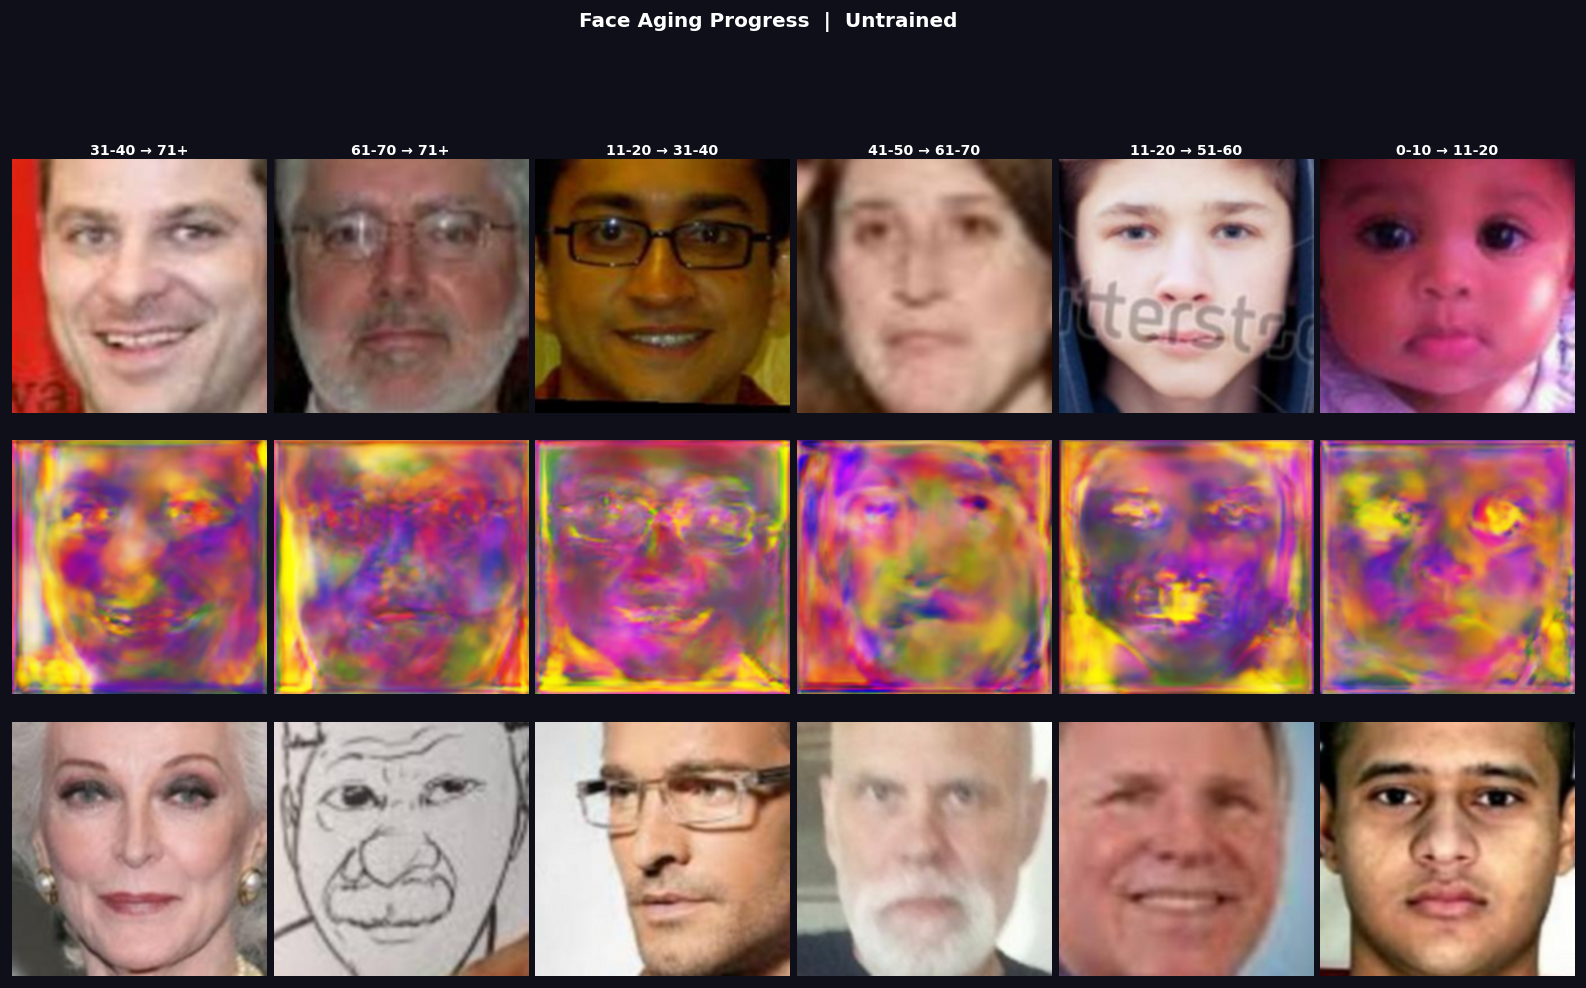

  📸 /content/drive/MyDrive/FaceAgingProject/visualizations/viz_untrained.png


In [ ]:
# ── Checkpoint utilities ─────────────────────────────────────
def save_checkpoint(epoch, history, best=False):
    ckpt = {
        'epoch': epoch,
        'encoder': encoder.state_dict(), 'age_embedder': age_embedder.state_dict(),
        'G': G.state_dict(), 'G_back': G_back.state_dict(), 'D': D.state_dict(),
        'opt_G': opt_G.state_dict(), 'opt_D': opt_D.state_dict(),
        'sched_G': sched_G.state_dict(), 'sched_D': sched_D.state_dict(),
        'scaler_G': scaler_G.state_dict(), 'scaler_D': scaler_D.state_dict(),
        'history': history,
        'config': {'IMG_SIZE':IMG_SIZE,'STYLE_DIM':STYLE_DIM,'NUM_CLASSES':NUM_CLASSES,
                   'IDENTITY_DIM':IDENTITY_DIM,'AGE_GROUPS':AGE_GROUPS,'LAMBDA':LAMBDA},
    }
    tag  = 'best' if best else f'epoch_{epoch:04d}'
    path = os.path.join(CKPT_PATH, f'ckpt_{tag}.pth')
    torch.save(ckpt, path)
    print(f'  ✅ Checkpoint saved → {path}')


def load_checkpoint(path):
    ckpt = torch.load(path, map_location=device)
    encoder.load_state_dict(ckpt['encoder'])
    age_embedder.load_state_dict(ckpt['age_embedder'])
    G.load_state_dict(ckpt['G']); G_back.load_state_dict(ckpt['G_back'])
    D.load_state_dict(ckpt['D'])
    opt_G.load_state_dict(ckpt['opt_G']); opt_D.load_state_dict(ckpt['opt_D'])
    sched_G.load_state_dict(ckpt['sched_G']); sched_D.load_state_dict(ckpt['sched_D'])
    scaler_G.load_state_dict(ckpt['scaler_G']); scaler_D.load_state_dict(ckpt['scaler_D'])
    print(f'  Resumed from epoch {ckpt["epoch"]}')
    return ckpt['epoch'], ckpt.get('history', [])


# ── Fixed visualization batch (LOCKED once, same every epoch) ──
# IMPORTANT: same batch = same faces → you can visually compare epoch-to-epoch
_viz_iter  = iter(val_loader)
_viz_batch = next(_viz_iter)
fixed_young = _viz_batch[0][:N_VIZ].clone()
fixed_old   = _viz_batch[1][:N_VIZ].clone()
fixed_y_grp = _viz_batch[2][:N_VIZ].clone()
fixed_o_grp = _viz_batch[3][:N_VIZ].clone()
del _viz_iter, _viz_batch
print(f'Fixed viz batch locked: {N_VIZ} faces')
print(f'  Young groups : {fixed_y_grp.tolist()}')
print(f'  Target groups: {fixed_o_grp.tolist()}')


def denorm(t):
    return (t.clamp(-1,1) + 1) / 2.0


@torch.no_grad()
def visualize_epoch(epoch):
    """
    Generates a 3-row grid on the FIXED val batch and displays it inline.
    Row 1 — Young input (always the same face)
    Row 2 — Fake old   (what the model produces THIS epoch)
    Row 3 — Real old   (unpaired reference — shows target appearance)
    Saved to VIZ_PATH/epoch_XXXX.png
    """
    encoder.eval(); age_embedder.eval(); G.eval(); arcface.eval()

    imgs_y  = fixed_young.to(device)
    imgs_o  = fixed_old.to(device)
    tgt_grp = fixed_o_grp.to(device)
    src_grp = fixed_y_grp.to(device)

    _, id_vec = encoder(imgs_y)
    arc_vec   = arcface(imgs_y)
    style     = age_embedder(tgt_grp, (id_vec + arc_vec) / 2.0)
    fake_old  = G(imgs_y, style)

    n = len(imgs_y)
    fig = plt.figure(figsize=(2.8 * n, 9))
    fig.patch.set_facecolor('#0f0f1a')

    gs = gridspec.GridSpec(3, n, figure=fig, hspace=0.05, wspace=0.03)
    row_labels  = ['Young input', 'Model output (epoch {:03d})'.format(epoch), 'Real old (ref)']
    row_colors  = ['#90caf9', '#a5d6a7', '#ef9a9a']
    row_borders = [None, '#a5d6a7', None]   # green border on generated row
    images      = [imgs_y, fake_old, imgs_o]

    for row in range(3):
        for col in range(n):
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(denorm(images[row][col]).cpu().permute(1,2,0).float().numpy(),
                      interpolation='lanczos')
            ax.axis('off')

            # Column header on first row
            if row == 0:
                y_lbl = AGE_GROUPS[int(src_grp[col].item())][2]
                o_lbl = AGE_GROUPS[int(tgt_grp[col].item())][2]
                ax.set_title(f'{y_lbl} → {o_lbl}', color='white',
                             fontsize=8.5, pad=3, fontweight='bold')

            # Row label on first column
            if col == 0:
                ax.set_ylabel(row_labels[row], color=row_colors[row],
                              fontsize=9, labelpad=5, fontweight='bold')

            # Green border on the generated row
            if row == 1:
                for sp in ax.spines.values():
                    sp.set_edgecolor('#66bb6a'); sp.set_linewidth(1.8)
            else:
                for sp in ax.spines.values():
                    sp.set_visible(False)

    tag = 'untrained' if epoch < 0 else f'epoch_{epoch:03d}'
    fig.suptitle(f'Face Aging Progress  |  {tag.replace("_"," ").title()}',
                 color='white', fontsize=12, fontweight='bold', y=1.01)

    save_p = os.path.join(VIZ_PATH, f'viz_{tag}.png')
    plt.savefig(save_p, dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)
    display(IPImage(filename=save_p))
    print(f'  📸 {save_p}')


# ── Resume logic ──────────────────────────────────────────────
start_epoch = 0
history     = []
best_g_loss = float('inf')

ckpt_files = sorted(Path(CKPT_PATH).glob('ckpt_epoch_*.pth'))
if ckpt_files:
    latest = str(ckpt_files[-1])
    print(f'Found checkpoint: {latest}')
    ans = input('Resume? (y/n): ').strip().lower()
    if ans == 'y':
        start_epoch, history = load_checkpoint(latest)
        start_epoch += 1
        best_g_loss = min(h['mean_g'] for h in history) if history else float('inf')
else:
    print('No checkpoint found — starting fresh.')


print('\n--- Pre-training visualization (untrained model) ---')
visualize_epoch(epoch=-1)

In [ ]:
def feature_matching_loss(feats_real, feats_fake):
    loss = 0.0

    for fr, ff in zip(feats_real, feats_fake):
        loss += torch.mean(torch.abs(fr - ff))

    return loss / max(len(feats_real), 1)

STARTING TRAINING
  Epochs       : 1 → 100
  Batch size   : 16
  N_CRITIC     : 2
  Mixed prec   : True
  Label smooth : 0.1
  D clip       : 0.5
  G clip       : 1.0
  Save every   : 10


Epoch 1/100: 100%|██████████| 768/768 [36:20<00:00,  2.84s/it, D=15.218, G=23.066, gap=2]


✔ Epoch 1/100 | D=15.1783 | G=23.0542 | cyc=0.2608 | id=0.3434 | LR=1.00e-04 | gap=2
  ✅ Checkpoint saved → /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_best.pth
⭐ New best model saved! G=23.0542


Epoch 2/100: 100%|██████████| 768/768 [05:09<00:00,  2.48it/s, D=10.804, G=20.822, gap=2]


✔ Epoch 2/100 | D=10.8041 | G=20.8150 | cyc=0.1905 | id=0.1885 | LR=9.99e-05 | gap=2
  ✅ Checkpoint saved → /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_best.pth
⭐ New best model saved! G=20.8150


...

✔ Epoch 8/100 | D=8.5474 | G=14.5026 | cyc=0.1101 | id=0.1014 | LR=9.84e-05 | gap=2
  ✅ Checkpoint saved → /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_best.pth
⭐ New best model saved! G=14.5026


Epoch 9/100: 100%|██████████| 768/768 [05:25<00:00,  2.36it/s, D=8.341, G=14.151, gap=2]


✔ Epoch 9/100 | D=8.3391 | G=14.1519 | cyc=0.1057 | id=0.1005 | LR=9.80e-05 | gap=2
  ✅ Checkpoint saved → /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_best.pth
⭐ New best model saved! G=14.1519


Epoch 10/100: 100%|██████████| 768/768 [05:24<00:00,  2.36it/s, D=8.130, G=13.702, gap=2]


✔ Epoch 10/100 | D=8.1283 | G=13.7025 | cyc=0.1022 | id=0.0980 | LR=9.76e-05 | gap=2
📸 Generating visualization...


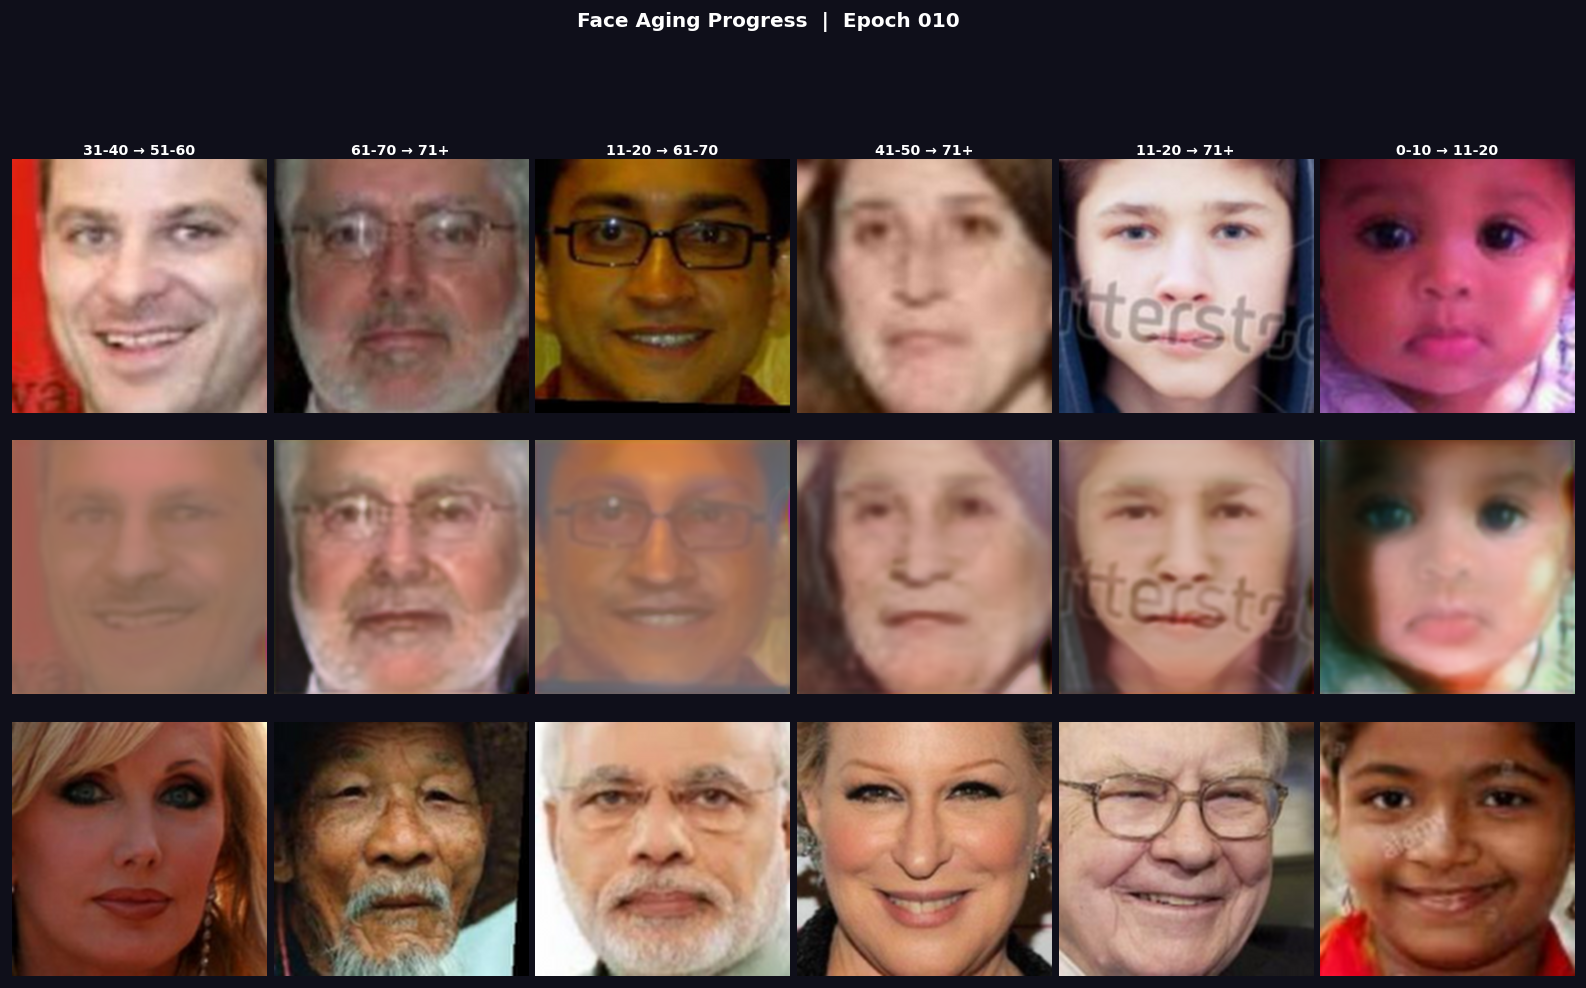

  📸 /content/drive/MyDrive/FaceAgingProject/visualizations/viz_epoch_010.png
💾 Saving checkpoint...
  ✅ Checkpoint saved → /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_epoch_0009.pth
  ✅ Checkpoint saved → /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_best.pth
⭐ New best model saved! G=13.7025


Epoch 11/100: 100%|██████████| 768/768 [05:38<00:00,  2.27it/s, D=7.910, G=13.364, gap=2]


✔ Epoch 11/100 | D=7.9082 | G=13.3667 | cyc=0.0969 | id=0.0962 | LR=9.71e-05 | gap=2
  ✅ Checkpoint saved → /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_best.pth
⭐ New best model saved! G=13.3667


Epoch 12/100: 100%|██████████| 768/768 [05:39<00:00,  2.27it/s, D=7.699, G=13.049, gap=2]


✔ Epoch 12/100 | D=7.6996 | G=13.0522 | cyc=0.0946 | id=0.0952 | LR=9.65e-05 | gap=2
  ✅ Checkpoint saved → /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_best.pth
⭐ New best model saved! G=13.0522


...

Epoch 15/100: 100%|██████████| 768/768 [05:39<00:00,  2.26it/s, D=7.234, G=12.396, gap=2]


✔ Epoch 15/100 | D=7.2313 | G=12.3974 | cyc=0.0837 | id=0.0933 | LR=9.46e-05 | gap=2
  ✅ Checkpoint saved → /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_best.pth
⭐ New best model saved! G=12.3974


Epoch 16/100: 100%|██████████| 768/768 [05:37<00:00,  2.28it/s, D=7.052, G=12.156, gap=2]


✔ Epoch 16/100 | D=7.0497 | G=12.1486 | cyc=0.0819 | id=0.0922 | LR=9.39e-05 | gap=2
  ✅ Checkpoint saved → /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_best.pth
⭐ New best model saved! G=12.1486


Epoch 17/100:  38%|███▊      | 294/768 [02:24<03:28,  2.28it/s, D=6.901, G=11.965, gap=2]

In [ ]:
# ============================================================
# STEP 16 — FINAL STABLE TRAINING LOOP
# Clean epoch numbering + NaN-safe + tqdm optimized
# ============================================================

print('=' * 70)
print('STARTING TRAINING')
print(f'  Epochs       : {start_epoch + 1} → {NUM_EPOCHS}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  N_CRITIC     : {N_CRITIC}')
print(f'  Mixed prec   : {MIXED_PREC}')
print(f'  Label smooth : {LABEL_SMOOTH}')
print(f'  D clip       : {D_CLIP}')
print(f'  G clip       : {G_CLIP}')
print(f'  Save every   : {SAVE_EVERY}')
print('=' * 70)

for epoch in range(start_epoch, NUM_EPOCHS):

    # ========================================================
    # HUMAN-READABLE EPOCH NUMBER
    # ========================================================
    epoch_num = epoch + 1

    # ========================================================
    # CURRICULUM UPDATE
    # ========================================================
    max_gap = get_curriculum_max_gap(epoch)

    train_dataset.set_max_gap(max_gap)

    # ========================================================
    # TRAIN MODE
    # ========================================================
    encoder.train()
    age_embedder.train()

    G.train()
    G_back.train()

    D.train()

    # ========================================================
    # LOSS ACCUMULATORS
    # ========================================================
    d_acc = {
        'd_real': 0,
        'd_fake': 0,
        'd_gp': 0,
        'd_age': 0,
        'd_total': 0
    }

    g_acc = {
        'g_adv': 0,
        'g_age': 0,
        'g_cycle': 0,
        'g_id': 0,
        'g_perc': 0,
        'g_fm': 0,
        'g_recon': 0,
        'g_total': 0
    }

    d_updates = 0
    g_updates = 0

    # ========================================================
    # tqdm PROGRESS BAR
    # ========================================================
    pbar = tqdm(
        train_loader,
        desc=f'Epoch {epoch_num}/{NUM_EPOCHS}',
        dynamic_ncols=True,
        leave=True
    )

    # ========================================================
    # TRAINING LOOP
    # ========================================================
    for batch_idx, (real_young, real_old, young_age, old_age) in enumerate(pbar):

        # ----------------------------------------------------
        # MOVE TO DEVICE
        # ----------------------------------------------------
        real_young = real_young.to(device, non_blocking=True)

        real_old = real_old.to(device, non_blocking=True)

        young_age = young_age.to(device, non_blocking=True)

        old_age = old_age.to(device, non_blocking=True)

        # ====================================================
        # DISCRIMINATOR STEP
        # ====================================================
        d_losses = train_discriminator(
            real_young,
            real_old,
            young_age,
            old_age
        )

        # ----------------------------------------------------
        # Skip NaN/INF corrupted D batches
        # ----------------------------------------------------
        if not d_losses.get('_skipped', False):

            for k in d_acc:
                d_acc[k] += d_losses[k]

            d_updates += 1

        # ====================================================
        # GENERATOR STEP
        # ====================================================
        if batch_idx % N_CRITIC == 0:

            g_losses = train_generator(
                real_young,
                real_old,
                young_age,
                old_age
            )

            # ------------------------------------------------
            # Skip NaN/INF corrupted G batches
            # ------------------------------------------------
            if not g_losses.get('_skipped', False):

                for k in g_acc:
                    g_acc[k] += g_losses[k]

                g_updates += 1

        # ====================================================
        # UPDATE tqdm DISPLAY
        # ====================================================
        if batch_idx % 20 == 0:

            mean_d_running = (
                d_acc['d_total'] / max(d_updates, 1)
            )

            mean_g_running = (
                g_acc['g_total'] / max(g_updates, 1)
            )

            pbar.set_postfix({
                'D': f'{mean_d_running:.3f}',
                'G': f'{mean_g_running:.3f}',
                'gap': max_gap
            })

    pbar.close()

    # ========================================================
    # EPOCH AVERAGES
    # ========================================================
    mean_d = (
        d_acc['d_total'] / max(d_updates, 1)
    )

    mean_g = (
        g_acc['g_total'] / max(g_updates, 1)
    )

    # ========================================================
    # LR SCHEDULERS
    # ========================================================
    sched_G.step()

    sched_D.step()

    # ========================================================
    # SAVE HISTORY
    # ========================================================
    rec = {

        'epoch': epoch_num,

        'mean_d': float(mean_d),

        'mean_g': float(mean_g),

        'gap': max_gap,

        **{
            k: float(v / max(d_updates, 1))
            for k, v in d_acc.items()
        },

        **{
            k: float(v / max(g_updates, 1))
            for k, v in g_acc.items()
        }
    }

    history.append(rec)

    # ========================================================
    # EPOCH SUMMARY
    # ========================================================
    print(
        f'✔ Epoch {epoch_num}/{NUM_EPOCHS} | '
        f'D={mean_d:.4f} | '
        f'G={mean_g:.4f} | '
        f'cyc={rec["g_cycle"]:.4f} | '
        f'id={rec["g_id"]:.4f} | '
        f'LR={sched_G.get_last_lr()[0]:.2e} | '
        f'gap={max_gap}'
    )

    # ========================================================
    # VISUALIZATION + CHECKPOINT
    # ========================================================
    if epoch_num % SAVE_EVERY == 0:

        print('📸 Generating visualization...')

        visualize_epoch(epoch_num)

        print('💾 Saving checkpoint...')

        save_checkpoint(
            epoch,
            history
        )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================
    if mean_g < best_g_loss:

        best_g_loss = mean_g

        save_checkpoint(
            epoch,
            history,
            best=True
        )

        print(
            f'⭐ New best model saved! '
            f'G={best_g_loss:.4f}'
        )

print('\n✅ TRAINING COMPLETE')

print('📸 Generating final visualization...')

visualize_epoch(NUM_EPOCHS)

In [ ]:
def feature_matching_loss(real_features, fake_features):
    loss = 0
    for r, f in zip(real_features, fake_features):
        loss += torch.mean(torch.abs(r - f))
    return loss

LOADING CHECKPOINT
✔ Loaded: /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_epoch_0065.pth
✔ Resuming from epoch: 66
✔ Best G loss: 12.05821124712626
✔ History size: 65
STARTING TRAINING
  Epochs       : 66 → 100
  Batch size   : 16
  N_CRITIC     : 1
  Mixed prec   : True
  Label smooth : 0.1
  D clip       : 0.5
  G clip       : 1.0
  Save every   : 5


Epoch 66/100:   0%|          | 0/768 [00:00<?, ?it/s]/tmp/ipykernel_7140/2523487356.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=MIXED_PREC):
/tmp/ipykernel_7140/2523487356.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=MIXED_PREC):
/tmp/ipykernel_7140/2523487356.py:151: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=MIXED_PREC):
Epoch 66/100: 100%|██████████| 768/768 [59:22<00:00,  4.64s/it, D=3.147, G=19.831, gap=7]


✔ Epoch 66/100 | D=3.1458 | G=19.8296 | cyc=0.0557 | id=0.0531 | LR=2.67e-05 | gap=7


Epoch 67/100: 100%|██████████| 768/768 [07:37<00:00,  1.68it/s, D=3.163, G=19.814, gap=7]


✔ Epoch 67/100 | D=3.1615 | G=19.8138 | cyc=0.0548 | id=0.0520 | LR=2.53e-05 | gap=7


...

✔ Epoch 68/100 | D=3.1323 | G=19.7324 | cyc=0.0542 | id=0.0513 | LR=2.40e-05 | gap=7


Epoch 69/100: 100%|██████████| 768/768 [07:41<00:00,  1.66it/s, D=3.144, G=19.715, gap=7]


✔ Epoch 69/100 | D=3.1437 | G=19.7156 | cyc=0.0540 | id=0.0508 | LR=2.27e-05 | gap=7


Epoch 70/100: 100%|██████████| 768/768 [07:39<00:00,  1.67it/s, D=3.117, G=19.690, gap=7]


✔ Epoch 70/100 | D=3.1184 | G=19.6891 | cyc=0.0531 | id=0.0501 | LR=2.14e-05 | gap=7
📸 Generating visualization...


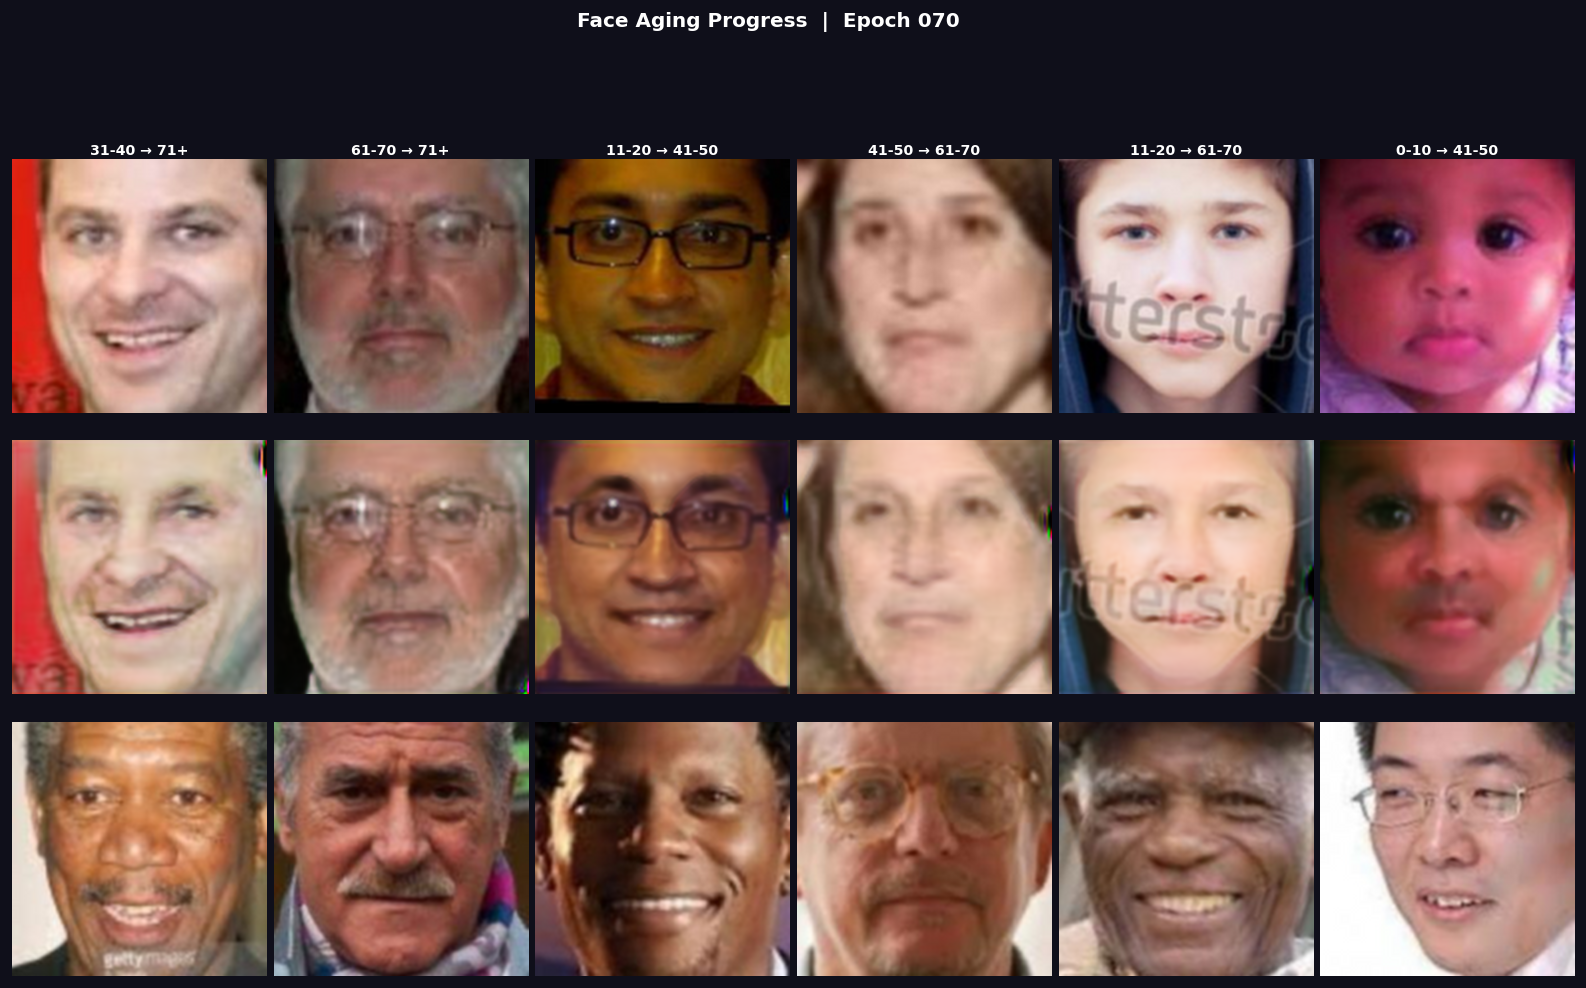

  📸 /content/drive/MyDrive/FaceAgingProject/visualizations/viz_epoch_070.png
💾 Saving checkpoint...
✅ Checkpoint saved → /content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_epoch_0070.pth


Epoch 71/100: 100%|██████████| 768/768 [07:50<00:00,  1.63it/s, D=3.137, G=19.648, gap=7]


✔ Epoch 71/100 | D=3.1377 | G=19.6442 | cyc=0.0530 | id=0.0497 | LR=2.02e-05 | gap=7


Epoch 72/100: 100%|██████████| 768/768 [07:47<00:00,  1.64it/s, D=3.111, G=19.606, gap=7]


✔ Epoch 72/100 | D=3.1124 | G=19.6069 | cyc=0.0524 | id=0.0495 | LR=1.89e-05 | gap=7


Epoch 73/100:  65%|██████▍   | 498/768 [05:00<02:34,  1.75it/s, D=3.171, G=19.581, gap=7]

In [ ]:
# ============================================================
# SETTINGS
# ============================================================

SAVE_EVERY = 5


# ============================================================
# SAFE CHECKPOINT SAVE FUNCTION
# ============================================================

def save_checkpoint(epoch, history, best=False, best_g_loss=None):

    checkpoint = {

        # ====================================================
        # TRAIN STATE
        # ====================================================
        'epoch': epoch,
        'history': history,
        'best_g_loss': best_g_loss,

        # ====================================================
        # MODELS
        # ====================================================
        'encoder': encoder.state_dict(),
        'age_embedder': age_embedder.state_dict(),

        'G': G.state_dict(),
        'G_back': G_back.state_dict(),

        'D': D.state_dict(),

        # ====================================================
        # OPTIMIZERS
        # ====================================================
        'opt_G': opt_G.state_dict(),
        'opt_D': opt_D.state_dict(),

        # ====================================================
        # SCHEDULERS
        # ====================================================
        'sched_G': sched_G.state_dict(),
        'sched_D': sched_D.state_dict(),
    }

    # ========================================================
    # SAVE PATH
    # ========================================================

    if best:

        path = (
            "/content/drive/MyDrive/FaceAgingProject/"
            "checkpoints/ckpt_best.pth"
        )

    else:

        path = (
            f"/content/drive/MyDrive/FaceAgingProject/"
            f"checkpoints/ckpt_epoch_{epoch:04d}.pth"
        )

    # ========================================================
    # SAVE CHECKPOINT
    # ========================================================

    torch.save(checkpoint, path)

    print(f"✅ Checkpoint saved → {path}")


# ============================================================
# RESUME FROM CHECKPOINT
# ============================================================

import torch

ckpt_path = (
    "/content/drive/MyDrive/FaceAgingProject/"
    "checkpoints/ckpt_epoch_0065.pth"
)


print("=" * 70)
print("LOADING CHECKPOINT")
print("=" * 70)

checkpoint = torch.load(
    ckpt_path,
    map_location=device
)

print("✔ Loaded:", ckpt_path)

# ============================================================
# RESTORE MODELS
# ============================================================

encoder.load_state_dict(
    checkpoint['encoder']
)

age_embedder.load_state_dict(
    checkpoint['age_embedder']
)

G.load_state_dict(
    checkpoint['G']
)

G_back.load_state_dict(
    checkpoint['G_back']
)

D.load_state_dict(
    checkpoint['D']
)

# ============================================================
# RESTORE OPTIMIZERS
# ============================================================

opt_G.load_state_dict(
    checkpoint['opt_G']
)

opt_D.load_state_dict(
    checkpoint['opt_D']
)

# ============================================================
# RESTORE SCHEDULERS
# ============================================================

sched_G.load_state_dict(
    checkpoint['sched_G']
)

sched_D.load_state_dict(
    checkpoint['sched_D']
)

# ============================================================
# RESTORE TRAIN STATE
# ============================================================

start_epoch = checkpoint['epoch']

history = checkpoint.get(
    'history',
    []
)

best_g_loss = checkpoint.get(
    'best_g_loss',
    None
)

# ============================================================
# OLD CHECKPOINT FIX
# ============================================================

if best_g_loss is None:

    best_g_loss = float('inf')

print(f"✔ Resuming from epoch: {start_epoch + 1}")
print(f"✔ Best G loss: {best_g_loss}")
print(f"✔ History size: {len(history)}")


# ============================================================
# TRAINING LOOP
# ============================================================

print("=" * 70)

print("STARTING TRAINING")

print(f"  Epochs       : {start_epoch + 1} → {NUM_EPOCHS}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  N_CRITIC     : {N_CRITIC}")
print(f"  Mixed prec   : {MIXED_PREC}")
print(f"  Label smooth : {LABEL_SMOOTH}")
print(f"  D clip       : {D_CLIP}")
print(f"  G clip       : {G_CLIP}")
print(f"  Save every   : {SAVE_EVERY}")

print("=" * 70)


for epoch in range(start_epoch, NUM_EPOCHS):

    # ========================================================
    # HUMAN READABLE EPOCH NUMBER
    # ========================================================

    epoch_num = epoch + 1

    # ========================================================
    # CURRICULUM LEARNING
    # ========================================================

    max_gap = get_curriculum_max_gap(epoch)

    train_dataset.set_max_gap(max_gap)

    # ========================================================
    # TRAIN MODE
    # ========================================================

    encoder.train()

    age_embedder.train()

    G.train()

    G_back.train()

    D.train()

    # ========================================================
    # LOSS ACCUMULATORS
    # ========================================================

    d_acc = {
        'd_real': 0,
        'd_fake': 0,
        'd_gp': 0,
        'd_age': 0,
        'd_total': 0
    }

    g_acc = {
        'g_adv': 0,
        'g_age': 0,
        'g_cycle': 0,
        'g_id': 0,
        'g_perc': 0,
        'g_fm': 0,
        'g_recon': 0,
        'g_total': 0
    }

    d_updates = 0

    g_updates = 0

    # ========================================================
    # tqdm PROGRESS BAR
    # ========================================================

    pbar = tqdm(
        train_loader,
        desc=f'Epoch {epoch_num}/{NUM_EPOCHS}',
        dynamic_ncols=True,
        leave=True
    )

    # ========================================================
    # BATCH LOOP
    # ========================================================

    for batch_idx, (
        real_young,
        real_old,
        young_age,
        old_age
    ) in enumerate(pbar):

        # ----------------------------------------------------
        # MOVE TO DEVICE
        # ----------------------------------------------------

        real_young = real_young.to(
            device,
            non_blocking=True
        )

        real_old = real_old.to(
            device,
            non_blocking=True
        )

        young_age = young_age.to(
            device,
            non_blocking=True
        )

        old_age = old_age.to(
            device,
            non_blocking=True
        )

        # ====================================================
        # DISCRIMINATOR STEP
        # ====================================================

        d_losses = train_discriminator(
            real_young,
            real_old,
            young_age,
            old_age
        )

        # ----------------------------------------------------
        # SKIP CORRUPTED D BATCHES
        # ----------------------------------------------------

        if not d_losses.get('_skipped', False):

            for k in d_acc:

                d_acc[k] += d_losses[k]

            d_updates += 1

        # ====================================================
        # GENERATOR STEP
        # ====================================================

        if batch_idx % N_CRITIC == 0:

            g_losses = train_generator(
                real_young,
                real_old,
                young_age,
                old_age
            )

            # ------------------------------------------------
            # SKIP CORRUPTED G BATCHES
            # ------------------------------------------------

            if not g_losses.get('_skipped', False):

                for k in g_acc:

                    g_acc[k] += g_losses[k]

                g_updates += 1

        # ====================================================
        # UPDATE tqdm DISPLAY
        # ====================================================

        if batch_idx % 20 == 0:

            mean_d_running = (
                d_acc['d_total'] / max(d_updates, 1)
            )

            mean_g_running = (
                g_acc['g_total'] / max(g_updates, 1)
            )

            pbar.set_postfix({

                'D': f'{mean_d_running:.3f}',

                'G': f'{mean_g_running:.3f}',

                'gap': max_gap
            })

    pbar.close()

    # ========================================================
    # EPOCH AVERAGES
    # ========================================================

    mean_d = (
        d_acc['d_total'] / max(d_updates, 1)
    )

    mean_g = (
        g_acc['g_total'] / max(g_updates, 1)
    )

    # ========================================================
    # LR SCHEDULER STEP
    # ========================================================

    sched_G.step()

    sched_D.step()

    # ========================================================
    # SAVE HISTORY
    # ========================================================

    rec = {

        'epoch': epoch_num,

        'mean_d': float(mean_d),

        'mean_g': float(mean_g),

        'gap': max_gap,

        **{
            k: float(v / max(d_updates, 1))
            for k, v in d_acc.items()
        },

        **{
            k: float(v / max(g_updates, 1))
            for k, v in g_acc.items()
        }
    }

    history.append(rec)

    # ========================================================
    # EPOCH SUMMARY
    # ========================================================

    print(

        f'✔ Epoch {epoch_num}/{NUM_EPOCHS} | '

        f'D={mean_d:.4f} | '

        f'G={mean_g:.4f} | '

        f'cyc={rec["g_cycle"]:.4f} | '

        f'id={rec["g_id"]:.4f} | '

        f'LR={sched_G.get_last_lr()[0]:.2e} | '

        f'gap={max_gap}'
    )

    # ========================================================
    # SAVE REGULAR CHECKPOINT
    # ========================================================

    if epoch_num % SAVE_EVERY == 0:

        print("📸 Generating visualization...")

        visualize_epoch(epoch_num)

        print("💾 Saving checkpoint...")

        save_checkpoint(

            epoch=epoch_num,

            history=history,

            best=False,

            best_g_loss=best_g_loss
        )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if mean_g < best_g_loss:

        best_g_loss = mean_g

        print(

            f"⭐ New best model saved! "

            f"G={best_g_loss:.4f}"
        )

        save_checkpoint(

            epoch=epoch_num,

            history=history,

            best=True,

            best_g_loss=best_g_loss
        )

print("\n✅ TRAINING COMPLETE")

print("📸 Generating final visualization...")

visualize_epoch(NUM_EPOCHS)

In [ ]:
import torch

ckpt_path = "/content/drive/MyDrive/FaceAgingProject/checkpoints/ckpt_epoch_0070.pth"

checkpoint = torch.load(
    ckpt_path,
    map_location=device
)

print("Checkpoint loaded.")

Checkpoint loaded.


In [ ]:
encoder.load_state_dict(checkpoint['encoder'])

age_embedder.load_state_dict(
    checkpoint['age_embedder']
)

G.load_state_dict(
    checkpoint['G']
)

G_back.load_state_dict(
    checkpoint['G_back']
)

print("Weights restored.")

Weights restored.


In [ ]:
encoder.eval()

age_embedder.eval()

G.eval()

G_back.eval()

print("Models set to eval mode.")

Models set to eval mode.


In [ ]:
import os
import torch

# ============================================================
# FINAL MODEL SAVE PATH
# ============================================================

FINAL_DIR = "/content/drive/MyDrive/FaceAgingProject/final_models"

os.makedirs(FINAL_DIR, exist_ok=True)

FINAL_PATH = os.path.join(
    FINAL_DIR,
    "final_model_epoch70.pth"
)

# ============================================================
# SAVE FINAL MODEL
# ============================================================

torch.save({

    # --------------------------------------------------------
    # MODELS
    # --------------------------------------------------------
    'encoder': encoder.state_dict(),

    'age_embedder': age_embedder.state_dict(),

    'G': G.state_dict(),

    'G_back': G_back.state_dict(),

    # --------------------------------------------------------
    # CONFIG
    # --------------------------------------------------------
    'config': {

        'IMG_SIZE': IMG_SIZE,

        'STYLE_DIM': STYLE_DIM,

        'IDENTITY_DIM': IDENTITY_DIM,

        'NUM_CLASSES': NUM_CLASSES,

        'AGE_GROUPS': AGE_GROUPS,

        'LAMBDA': LAMBDA,
    },

    # --------------------------------------------------------
    # TRAINING INFO
    # --------------------------------------------------------
    'history': history,

    'best_g_loss': best_g_loss,

    'total_epochs': 70,

}, FINAL_PATH)

# ============================================================
# DONE
# ============================================================

print(f'✅ Final model saved: {FINAL_PATH}')
print()

print('Load in testing notebook:')
print("ckpt = torch.load(FINAL_PATH, map_location=device)")
print("encoder.load_state_dict(ckpt['encoder'])")
print("age_embedder.load_state_dict(ckpt['age_embedder'])")
print("G.load_state_dict(ckpt['G'])")
print("encoder.eval()")
print("age_embedder.eval()")
print("G.eval()")

✅ Final model saved: /content/drive/MyDrive/FaceAgingProject/final_models/final_model_epoch70.pth

Load in testing notebook:
ckpt = torch.load(FINAL_PATH, map_location=device)
encoder.load_state_dict(ckpt['encoder'])
age_embedder.load_state_dict(ckpt['age_embedder'])
G.load_state_dict(ckpt['G'])
encoder.eval()
age_embedder.eval()
G.eval()
